In [145]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [146]:
load_dotenv()

True

In [147]:
genarator_llm = ChatGroq(
    model='openai/gpt-oss-20b'
)

evaluator_llm = ChatGroq(
    model = 'openai/gpt-oss-20b'
)

optimizer_llm = ChatGroq(
    model = 'openai/gpt-oss-20b'
)

In [148]:
from pydantic import BaseModel, Field

class TweetEval(BaseModel):
    evaluation : Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field (..., description="feedback for the tweet.")

In [149]:
struct_eval_llm = evaluator_llm.with_structured_output(TweetEval)

In [150]:
#state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation : Literal["approved", "needs_improvement"]
    feedback : str
    iteration : int
    max_iteration : int
    tweet_hist : Annotated[list[str], operator.add]
    fdbk_hist : Annotated[list[str], operator.add]

In [151]:
def gen_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    response = genarator_llm.invoke(messages).content

    return {'tweet' : response, 'tweet_hist' : [response]}


In [152]:
def eval_tweet(state: TweetState):
    messages = [
        SystemMessage(
            content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."
        ),
        HumanMessage(
            content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:
1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- It ends with generic, throwaway, or deflating lines that weaken the humor
"""
        ),
    ]

    response = struct_eval_llm.invoke(messages)

    return {
        "evaluation": response.evaluation,
        "feedback": response.feedback,
        "fdbk_hist": [response.feedback],
    }

In [153]:
def optm_tweet(state: TweetState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet' : response, 'iteration': iteration, 'tweet_hist' : [response]}


In [154]:
def route_eval(state : TweetState):
    if state['evaluation'] == 'approved' or state['iteration']>= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [155]:
graph = StateGraph(TweetState)

graph.add_node('gen', gen_tweet)
graph.add_node('eval', eval_tweet)
graph.add_node('optm', optm_tweet)

In [156]:
graph.add_edge(START, 'gen')
graph.add_edge('gen', 'eval')

graph.add_conditional_edges('eval', route_eval,{
    'approved' : END,
    'needs_improvement' : 'optm'
})

graph.add_edge('optm', 'eval')

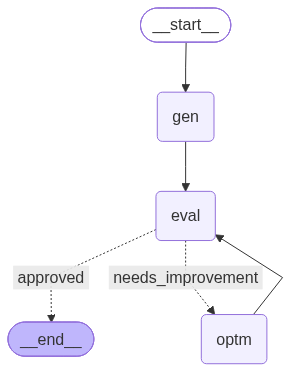

In [157]:
workflow = graph.compile()
workflow

In [167]:
initial_state = {
    "topic": "GG era in indian Cricket",
    "iteration": 1,
    "max_iteration": 5
}


In [168]:
result = workflow.invoke(initial_state)
result

{'topic': 'GG era in indian Cricket',
 'tweet': 'GG era in Indian cricket: when ‘GG’ after a wicket becomes the national anthem of disappointment, louder than the crowd. It’s the “Sorry, my bad” meme we all cheer. #GGera',
 'evaluation': 'approved',
 'feedback': "Solid tweet—concise, witty, and spot-on with the #GGera meme. It's fresh enough to stand out, hits the humor mark, and the hashtag will help it spread. No formatting issues.",
 'iteration': 2,
 'max_iteration': 5,
 'tweet_hist': ['GG era in Indian cricket: when you Google “GG” you’re looking for “Good Game” not a new team name. Commentators say “GG” after every wicket, and we’re all chanting it like a national anthem of disappointment. #GGera',
  'GG era in Indian cricket: when ‘GG’ after a wicket becomes the national anthem of disappointment, louder than the crowd. It’s the “Sorry, my bad” meme we all cheer. #GGera'],
 'fdbk_hist': ['The tweet lands on the comedic side but feels a bit generic; the punchline is more an observa

In [169]:
for tweet in result['tweet_hist']:
    print(tweet)

GG era in Indian cricket: when you Google “GG” you’re looking for “Good Game” not a new team name. Commentators say “GG” after every wicket, and we’re all chanting it like a national anthem of disappointment. #GGera
GG era in Indian cricket: when ‘GG’ after a wicket becomes the national anthem of disappointment, louder than the crowd. It’s the “Sorry, my bad” meme we all cheer. #GGera


In [176]:
for i, tweet in enumerate(result['tweet_hist'], 1):
    print(f"\n{'='*50} Tweet #{i} {'='*50}")
    print(tweet.strip())


================================================== Tweet #1 ==================================================
GG era in Indian cricket: when you Google “GG” you’re looking for “Good Game” not a new team name. Commentators say “GG” after every wicket, and we’re all chanting it like a national anthem of disappointment. #GGera

================================================== Tweet #2 ==================================================
GG era in Indian cricket: when ‘GG’ after a wicket becomes the national anthem of disappointment, louder than the crowd. It’s the “Sorry, my bad” meme we all cheer. #GGera
